## Visualizing the Link Between Normal, Cancer, CCR8 treated, and PD1 treated

### Data visualization, PCA and UMAP using the cancer dataset.

We first load data into a Pandas DataFrame, It dives into the realm of dimensionality reduction by performing PCA and UMAP on the dataset. 

In [8]:
# These are the package import statements. As you can see, you'll be using pandas to manipulate raw data and matplotlib and seaborn for data visualization.
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
SRS_Data = pd.read_excel('Comparison_Intensity_ratio.xlsx')
print(SRS_Data.head(10)) 


    Types  Intensity_X  Intensity_Y     Ratio
0  Normal     0.096829     0.404538  0.806871
1  Normal     0.145601     0.440429  0.751547
2  Normal     0.364497     0.547700  0.600419
3  Normal     0.369566     0.501395  0.575680
4  Normal     0.099619     0.440404  0.815529
5  Normal     0.326115     0.541056  0.623932
6  Normal     0.876589     0.960324  0.522792
7  Normal     0.370859     0.526136  0.586554
8  Normal     0.106705     0.472268  0.815699
9  Normal     0.445746     0.604142  0.575435


# PCA with SRS Data

In [9]:
# Import additional packages for doing PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [10]:
# Features
X = SRS_Data[['Intensity_X', 'Intensity_Y', 'Ratio']]
 
# Target variable
y = SRS_Data['Types']
 
# Standardize the features
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
 
# Perform PCA
pca2 = PCA(n_components=2)
pca2.fit(X_scaled)
principalComponents = pca2.fit_transform(X_scaled)
 
# Calculate variance explained by the first two principal components
variance_explained_by_first_two_components = np.sum(pca2.explained_variance_ratio_[:2])
print(f"Variance explained by the first two principal components: {variance_explained_by_first_two_components:.2f}")
 
# Define new dataframe with principal components
df_pca = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])
df_pca = pd.concat([df_pca, SRS_Data[['Types']]], axis=1)
 

Variance explained by the first two principal components: 0.97


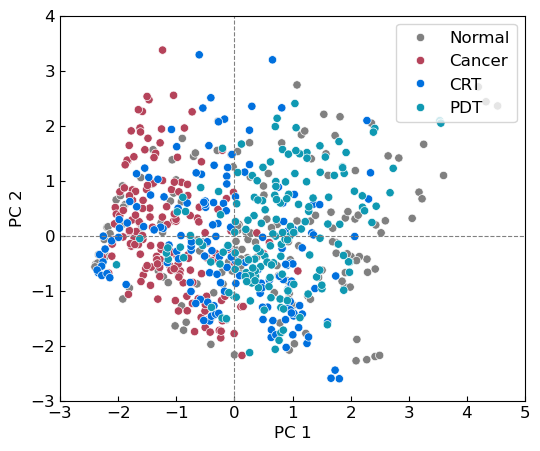

In [11]:

# Plotting
plt.figure(figsize=(6, 5))
axes = plt.gca()  # Get the current axis to pass to seaborn
sns.scatterplot(
    data=df_pca, 
    x='principal component 1', 
    y='principal component 2', 
    hue='Types', 
    palette={'Normal': 'gray', 'Cancer': (181/255,67/255,90/255), 'CRT': (0/255,112/255,222/255), 'PDT':  (15/255,153/255,178/255)}, 
    ax=axes
)

# Set axis limits
plt.xlim(-3, 5)  # Adjust these limits as needed
plt.ylim(-3, 4)  # Adjust these limits as needed
 
# Add lines for x=0 and y=0
plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
 
# plt.title('PC1 vs PC2 by Types')
plt.xlabel('PC 1', fontsize=12)
plt.ylabel('PC 2', fontsize=12)



plt.tick_params(axis='both', which='major', labelsize=12, direction='in')  # Set the font size for major ticks
 
# Set legend with font size
plt.legend( loc='upper right', fontsize=12)
plt.savefig("PCA.svg", dpi=300,format="svg")
plt.show()

# UMAP with SRS Data

In [ ]:
from umap import UMAP

# reducer = UMAP(a=None, angular_rp_forest=False, b=None,
#      force_approximation_algorithm=False, init='spectral', learning_rate=1.0,
#      local_connectivity=1.0, low_memory=False, metric='euclidean',
#      metric_kwds=None, min_dist=0.09, n_components=2, n_epochs=None,
#      n_neighbors=8, negative_sample_rate=5, output_metric='euclidean',
#      output_metric_kwds=None, random_state=42, repulsion_strength=1.0,
#      set_op_mix_ratio=1.0, spread=1.0, target_metric='categorical',
#      target_metric_kwds=None, target_n_neighbors=-1, target_weight=0.5,
#      transform_queue_size=4.0, transform_seed=42, unique=False, verbose=False)

# normalize features
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# umap_embedding = reducer.fit_transform(X_scaled)


# UMAP
umap_reducer = UMAP(n_components=2)
umap_embedding = umap_reducer.fit_transform(X_scaled)


# convert into DataFrame
df_umap = pd.DataFrame(data=umap_embedding, columns=['UMAP 1', 'UMAP 2'])
df_umap = pd.concat([df_umap, SRS_Data[['Types']]], axis=1)

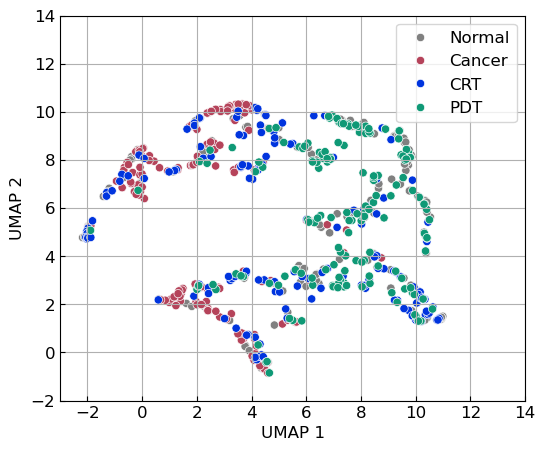

In [ ]:
# plot
plt.figure(figsize=(6, 5))
axes = plt.gca() 
sns.scatterplot(
    data=df_umap, 
    x='UMAP 1', 
    y='UMAP 2', 
    hue='Types', 
    palette={'Normal': 'gray', 'Cancer': (181/255,67/255,90/255), 'CRT': (0/255,52/255,222/255), 'PDT':  (15/255,153/255,118/255)}, 
    ax=axes
)

plt.xlim(-3, 14)
plt.ylim(-2, 14)

plt.grid(True)

# plt.title('UMAP 1 vs UMAP 2 by Types')
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12, direction='in')
# Set legend with font size
plt.legend( loc='upper right', fontsize=12)
plt.savefig("UMAP.svg", dpi=300,format="svg")
plt.show()